In [227]:
import numpy as np
import matplotlib.pyplot as plt
import pyshtools as pysh
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.feature_selection import VarianceThreshold
import os 
from meshplot import plot, subplot 
import anndata as ad
import pandas as pd

import igl 
from scipy.sparse.linalg import eigsh
from tqdm import tqdm

In [134]:
import importlib

import src.meshharm 
import src.fatemarkers
importlib.reload(src.meshharm)
importlib.reload(src.fatemarkers)
from src.fatemarkers import FateMarkers

In [228]:
res = np.load('sim/multi_shape_bof_results_raw_value.npz', allow_pickle=True)
ids = res['filtered_ids']
times = res['filtered_time']
spectrums = res['filtered_spectrums']
areas = res['filtered_areas']
complexities = res['filtered_complexities']

res = np.load('sim/vocab_new.npz', allow_pickle=True)
vocab = res['vocab']
scaler = res['scaler'].item() 
sigma = res['sigma']
ts = res['ts']

print(spectrums.shape) 

(2667, 8, 8)


In [331]:
dim_red_results = pd.read_csv('Data/tsne_results_raw_value.csv')
print(dim_red_results.head())
print(dim_red_results.shape)

        label_uid      tsne1      tsne2  complexity
0   day1p5_A01_96 -18.229230 -33.572823    1.956240
1  day1p5_A01_140  -6.559122 -32.572980    1.960171
2  day1p5_A01_154 -23.033148 -25.809118    1.963289
3   day1p5_A01_41 -29.130922 -25.921164    1.964749
4   day1p5_A01_68 -17.985437 -46.310333    1.959688
(2667, 4)


In [389]:
# randomly select organoids of high complexities 
high_complexity_df = dim_red_results[dim_red_results['complexity'] > 5.5]

indices = np.random.choice(high_complexity_df.index, size=5, replace=False)

list_of_ids = high_complexity_df.loc[indices, 'label_uid'].tolist()


In [386]:
list_of_ids = ['day4p5-more_C01_85', 'day4p5_B06_51', 'day4_A02_31', 'day4p5-more_C03_143', 'day4p5_A06_31'] 

In [477]:
list_of_ids = ['day4p5_B06_34', 'day3p5_A03_69']

Selected organoid ID: day4p5_B06_34, Closest organoid ID: day4p5-more_C02_123
Selected organoid ID: day3p5_A03_69, Closest organoid ID: day4p5-more_C01_75


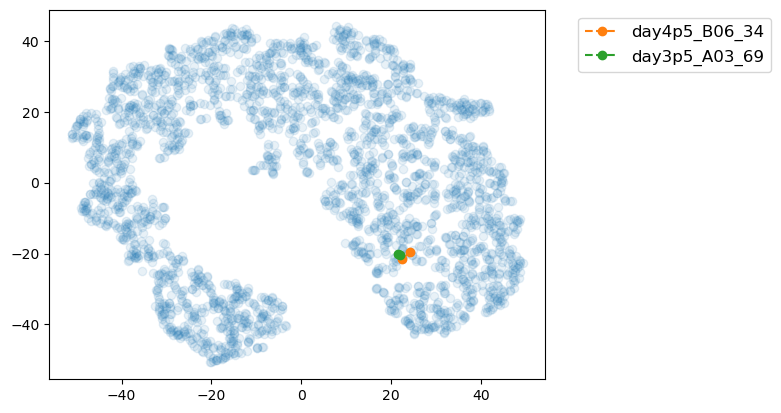

In [478]:
closest_ids = [] 
weights = np.sqrt(np.array([2, 2, 1, 0.1, 1, 2, 0.1, 2])) 
ks = np.ones(spectrums.shape[1])

plt.plot(dim_red_results['tsne1'], dim_red_results['tsne2'], 'o', alpha=0.1)
for i in list_of_ids: 
    # find the organoid that's closest to the selected id in terms of distance in reduced space 
    org_index = dim_red_results[dim_red_results['label_uid'] == i].index[0]
    dists = np.linalg.norm((spectrums - spectrums[org_index][np.newaxis, :, :]) * weights[np.newaxis, np.newaxis, :] * ks[np.newaxis, :, np.newaxis], axis=(1, 2))
    dists[dists == 0]  = np.inf  # exclude itself
    closest_index = np.argmin(dists) 
    closest_id = dim_red_results.loc[closest_index, 'label_uid']
    print(f"Selected organoid ID: {i}, Closest organoid ID: {closest_id}")
    closest_ids.append(closest_id)

    xs = [dim_red_results.loc[org_index, 'tsne1'], dim_red_results.loc[closest_index, 'tsne1']]
    ys = [dim_red_results.loc[org_index, 'tsne2'], dim_red_results.loc[closest_index, 'tsne2']]
    plt.plot(xs, ys, 'o--', alpha=1, label=f"{i}")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=12)
plt.show() 


In [479]:
# list_of_ids = ['day4p5-more_C02_34', 'day4p5-more_C03_55']

for (i, id) in enumerate(list_of_ids): 
    print(id)
    label = id.split('_')
    path = path = f'Data/20251001/{label[0]}/r0.zarr/{label[1][0]}/{label[1][1:]}/0_fused_zillum_registered/meshes/nnorg_linked_multi_annotated_class/{label[2]}.vtp'
    m = FateMarkers()
    m.load_mesh_from_file(path) 
    m.align_with_pca()


    lgr5_index = m.field_names.index('0.C02.percentile99_class')
    plot(m.v, m.f, c=m.fields[:, lgr5_index])

    cloest_id = closest_ids[i]
    print(f"Closest organoid ID: {cloest_id}")
    label = cloest_id.split('_')
    path = path = f'Data/20251001/{label[0]}/r0.zarr/{label[1][0]}/{label[1][1:]}/0_fused_zillum_registered/meshes/nnorg_linked_multi_annotated_class/{label[2]}.vtp'
    m = FateMarkers()
    m.load_mesh_from_file(path) 
    m.align_with_pca()

    lgr5_index = m.field_names.index('0.C02.percentile99_class')
    plot(m.v, m.f, c=m.fields[:, lgr5_index])

day4p5_B06_34


Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(-0.195884…

Closest organoid ID: day4p5-more_C02_123


Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(0.0159804…

day3p5_A03_69


Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(0.5560634…

Closest organoid ID: day4p5-more_C01_75


Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(0.1273226…